In [1]:
# 1. Cài đặt các thư viện cần thiết
!pip install -q mne scikit-learn matplotlib pandas numpy torch

import os
import gc
import random
import warnings
import glob
from collections import Counter

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, confusion_matrix

# Tắt cảnh báo hệ thống
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")

print("Đã chuẩn bị xong môi trường và các thư viện!")

Đã chuẩn bị xong môi trường và các thư viện!


In [3]:
# Đường dẫn trực tiếp tới thư mục dữ liệu đã được Kaggle giải nén sẵn
extract_target = "/kaggle/input/datasets/ledaihoangnguyentmu/sleep-edf-database-expanded-1-0-0-zip/sleep-edf-database-expanded-1.0.0"

# Kiểm tra xem đường dẫn có hoạt động chính xác không
if os.path.exists(extract_target):
    print("✅ Đã kết nối thành công tới bộ dữ liệu Sleep-EDF!")
    print("Các thư mục con sẵn sàng sử dụng:")
    
    # Liệt kê các file/thư mục bên trong để chắc chắn
    files = os.listdir(extract_target)
    for f in files:
        print(f" - {f}")
else:
    print("⚠️ Không tìm thấy thư mục dữ liệu, vui lòng kiểm tra lại đường dẫn.")

✅ Đã kết nối thành công tới bộ dữ liệu Sleep-EDF!
Các thư mục con sẵn sàng sử dụng:
 - sleep-cassette
 - SHA256SUMS.txt
 - SC-subjects.xls
 - RECORDS
 - RECORDS-v1
 - ST-subjects.xls
 - sleep-telemetry


In [ ]:
# Cấu hình siêu tham số
SEED = 42
HIDDEN_SIZE = 512    # Rất tốt, tăng sức mạnh ghi nhớ cho LSTM
NUM_LAYERS = 2       # SỬA: Đưa về 2 (hoặc 3) để mô hình hội tụ tốt, không bị lỗi đạo hàm
DROPOUT = 0.2        # Rất tốt, giúp mô hình dễ học hơn 0.3 cũ
ALPHA = 0.15         # Rất tốt, độ nhạy của Focal Loss với mẫu khó phân loại
WEIGHT_DECAY = 1e-4 # Rất tốt, giúp mô hình tổng quát hơn

WINDOW_SIZE = 5      # SỬA: Số lẻ, gọn gàng (nhìn 2 epoch trước, 2 epoch sau = 2.5 phút)
CENTER_IDX = 2       # SỬA: Tâm của cửa sổ 5 là 2. Công thức: (5 - 1) / 2 = 2

BATCH_SIZE = 32      # Okie, nếu máy báo lỗi Out of Memory thì hạ xuống 32 nhé
LEARNING_RATE = 1e-3 # Tạm ổn, nếu chạy mà thấy Loss trồi sụt thì hạ xuống 5e-4
MAX_EPOCHS = 100     # Rất tốt, cho mô hình cơ hội học lâu hơn
PATIENCE = 10         # GỢI Ý: Nên tăng từ 5 lên 7 hoặc 10, vì MAX_EPOCHS tận 100,
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PADDING_MINUTES = 0  # Số phút cần padding ở đầu và cuối mỗi night (tính theo số epoch)
MAX_BREAK_MINUTES = 45  # Số phút tối đa cho phép gián đoạn giữa các giai đoạn ngủ (tính theo số epoch)
KFOLD = 5           # Số lượng fold cho K-Fold Cross Validation

CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
VALID_STAGES = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R']
MAPPING_STAGES = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(SEED)

In [ ]:
# --- EMAC EARLY STOPPING ĐỒNG BỘ ---
class EMAEarlyStopping:
    def __init__(self, patience=5, alpha=0.15):
        self.patience = patience
        self.alpha = alpha
        self.best_ema_score = -float('inf')
        self.ema_score = None
        self.patience_counter = 0
        self.best_model_state = None

    def step(self, current_score, model):
        if self.ema_score is None:
            self.ema_score = current_score
        else:
            self.ema_score = self.alpha * current_score + (1 - self.alpha) * self.ema_score

        if self.ema_score > self.best_ema_score:
            self.best_ema_score = self.ema_score
            self.patience_counter = 0
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.patience_counter += 1
            return self.patience_counter >= self.patience

    def restore_best(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

In [ ]:
# --- KHỞI TẠO DATASET CHO SÓNG THÔ ĐƠN LẺ (MỖI EPOCH LÀ 1 ĐOẠN SÓNG 30S) ---
class RawSignalsDataset(Dataset):
    def __init__(self, file_data_list):
        """
        file_data_list: Danh sách các tuple (X_raw, y_labels) trích xuất từ mỗi file
        """
        X_all, y_all = [], []
        for x_mat, y_vec in file_data_list:
            X_all.append(x_mat)
            y_all.append(y_vec)

        if len(X_all) > 0:
            self.X = np.concatenate(X_all, axis=0).astype(np.float32) # Shape: (N, 1, 3000)
            self.y = np.concatenate(y_all, axis=0).astype(np.int64)
        else:
            self.X = np.empty((0, 1, 3000), dtype=np.float32)
            self.y = np.empty((0,), dtype=np.int64)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)

def load_raw_edf_folder(pattern, padding_minutes=30, max_break_minutes=45):
    all_files = glob.glob(pattern, recursive=True)
    psg_files = sorted([f for f in all_files if f.endswith("PSG.edf")])
    hyp_files = sorted([f for f in all_files if f.endswith("Hypnogram.edf")])

    file_data = []
    
    # Định dạng số lượng epoch cần padding/break dựa trên thời gian 30s mỗi epoch
    padding_epochs = int(padding_minutes * 60 / 30)
    max_break_epochs = int(max_break_minutes * 60 / 30)
    wake_id = 0 # Theo MAPPING_STAGES thì "Sleep stage W" là 0

    for psg, hyp in zip(psg_files, hyp_files):
        try:
            raw = mne.io.read_raw_edf(psg, preload=True, verbose=False)
            
            # --- BƯỚC 1: LẤY 3 KÊNH CHUẨN ĐỐI VỚI BỘ SLEEP-EDF ---
            # Tìm chính xác tên kênh dựa trên chuỗi có sẵn (tránh việc sai lệch thứ tự index giữa các file)
            ch_names = raw.ch_names
            eeg_ch = [c for c in ch_names if "Fpz-Cz" in c][0]
            eog_ch = [c for c in ch_names if "EOG" in c][0]
            emg_ch = [c for c in ch_names if "EMG" in c][0]
            
            # Chỉ giữ lại và sắp xếp đúng thứ tự 3 kênh yêu cầu
            raw.pick_channels([eeg_ch, eog_ch, emg_ch])
            
            # Áp dụng bộ lọc dải tần (0.5 - 30Hz thông dụng cho Sleep Staging)
            raw.filter(0.5, 30.0, fir_design='firwin', verbose=False)
            raw.resample(100, verbose=False) # 100Hz -> 30 giây = 3000 sampling points
            
            # Lấy ma trận dữ liệu sau lọc: Shape lúc này sẽ là (3, tổng_số_sample)
            ch_data = raw.get_data()

            # --- BƯỚC 2: ĐỌC VÀ ĐỒNG BỘ HÓA NHÃN ---
            annotations = mne.read_annotations(hyp)
            raw.set_annotations(annotations[np.isin(annotations.description, VALID_STAGES)], emit_warning=False)
            events, event_id = mne.events_from_annotations(raw, event_id=MAPPING_STAGES, chunk_duration=30.0, verbose=False)

            if len(events) == 0:
                continue

            # --- BƯỚC 3: IMPLEMENT LOGIC LỌC WAKE CỦA DEEPSLEEPNET ---
            labels = events[:, -1]
            total_len = len(labels)
            
            non_wake_indices = np.where(labels != wake_id)[0]
            if len(non_wake_indices) == 0:
                continue # Nếu file toàn là Wake (không ngủ tí nào) thì bỏ qua file này
                
            last_sleep_idx = non_wake_indices[-1]
            first_sleep_idx = non_wake_indices[0]
            
            current_wake_streak = 0
            has_slept = False

            for i in range(total_len):
                if labels[i] != wake_id:
                    if not has_slept:
                        first_sleep_idx = i
                        has_slept = True
                    current_wake_streak = 0
                else:
                    if has_slept:
                        current_wake_streak += 1
                        if current_wake_streak >= max_break_epochs:
                            has_slept = False
                            current_wake_streak = 0

            start_idx = max(0, first_sleep_idx - padding_epochs)
            end_idx = min(total_len - 1, last_sleep_idx + padding_epochs)

            if start_idx >= end_idx:
                start_idx = max(0, non_wake_indices[0] - padding_epochs)

            # Cắt danh sách các sự kiện (events) theo vùng biên đã được lọc
            filtered_events = events[start_idx : end_idx + 1]
            
            # --- BƯỚC 4: TRÍCH XUẤT ĐOẠN TÍN HIỆU ĐÃ LỌC ---
            X_file, y_file = [], []
            for ev in filtered_events:
                start_samp = ev[0]
                end_samp = start_samp + 3000
                
                if end_samp <= ch_data.shape[1]:
                    # Lấy cả 3 kênh tín hiệu tại đoạn 30s này: Shape (3, 3000)
                    segment = ch_data[:, start_samp:end_samp]
                    
                    # Chuẩn hóa Z-score cục bộ trên từng kênh một một cách độc lập
                    for ch in range(3):
                        mean = np.mean(segment[ch])
                        std = np.std(segment[ch]) + 1e-8
                        segment[ch] = (segment[ch] - mean) / std
                        
                    X_file.append(segment)
                    y_file.append(ev[-1])

            if X_file:
                # Stack lại thành mảng NumPy. 
                # Shape đầu ra: (N_epochs_đã_lọc, 3, 3000) -> Đúng cấu trúc đầu vào đa kênh của DeepSleepNet
                X_file = np.stack(X_file, axis=0)
                y_file = np.array(y_file)
                file_data.append((X_file, y_file))
                
                print(f"File {np.basename(psg)}: Đã lọc từ {total_len} còn {len(y_file)} epochs (3 kênh).")
                
        except Exception as e:
            print(f"Lỗi khi xử lý file {psg}: {e}")
            continue
            
    return file_data

In [ ]:
class DeepSleepNet(nn.Module):
    def __init__(self, num_classes=5):
        super(DeepSleepNet, self).__init__()

        # Nhánh 1: Bộ lọc CNN kích thước nhỏ (Fine features)
        self.features1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=50, stride=6, padding=24, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(kernel_size=8, stride=8, padding=2),
            nn.Dropout(DROPOUT),
            nn.Conv1d(64, 128, kernel_size=8, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=8, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4, padding=1)
        )

        # Nhánh 2: Bộ lọc CNN kích thước lớn (Coarse features)
        self.features2 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=400, stride=50, padding=175, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4, padding=1),
            nn.Dropout(DROPOUT),
            nn.Conv1d(64, 128, kernel_size=6, stride=1, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=6, stride=1, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        )

        self.dropout = nn.Dropout(DROPOUT)

        # ======================================================================
        # 🔥 CẬP NHẬT TẠI ĐÂY: Thay thế 128*9 + 128*7 (2048) thành 2688
        # ======================================================================
        self.classifier = nn.Linear(2688, num_classes)

    def forward(self, x):
        x1 = self.features1(x)
        x2 = self.features2(x)

        x1 = x1.view(x1.size(0), -1)
        x2 = x2.view(x2.size(0), -1)

        x = torch.cat((x1, x2), dim=1)
        x = self.dropout(x)
        return self.classifier(x)

In [ ]:
# --- CẤU HÌNH LOSS VÀ TRAINING VÒNG LẶP NÂNG CAO ---
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.gamma, self.smoothing = gamma, smoothing
    def forward(self, logits, targets):
        C = logits.size(1)
        log_prob = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, self.smoothing / (C - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        ce_loss = -(smooth_targets * log_prob).sum(dim=1)
        pt = torch.exp(log_prob).gather(1, targets.unsqueeze(1)).squeeze(1)
        return ((1.0 - pt) ** self.gamma * ce_loss).mean()

def train_deep_net(model, train_loader, val_loader):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=8, T_mult=1, eta_min=1e-6)
    criterion = FocalLoss()
    stopper = EMAEarlyStopping(patience=PATIENCE, alpha=ALPHA)

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            criterion(model(x_b), y_b).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for x_b, y_b in val_loader:
                val_preds.extend(model(x_b.to(DEVICE)).argmax(dim=1).cpu().tolist())
                val_targets.extend(y_b.tolist())

        epoch_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
        scheduler.step()

        if stopper.step(epoch_f1, model): break

    stopper.restore_best(model)

def evaluate_deep_loader(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            preds.extend(logits.argmax(dim=1).cpu().tolist())
            targets.extend(y.tolist())
            probs.extend(torch.softmax(logits, dim=1).cpu().tolist())
    return np.array(targets), np.array(preds), np.array(probs)

In [ ]:
# --- CẬP NHẬT HÀM TRAIN ĐỂ LƯU LẠI LỊCH SỬ (HISTORY) ---
def train_deep_net_with_history(model, train_loader, val_loader):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=8, T_mult=1, eta_min=1e-6)
    criterion = FocalLoss()
    stopper = EMAEarlyStopping(patience=PATIENCE, alpha=ALPHA)

    # Khởi tạo các list lưu lịch sử qua từng epoch giống ANN
    history = {
        'train_loss': [],
        'val_f1': [],
        'ema_val_f1': []
    }

    best_epoch = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            running_loss += loss.item()

        # Tính Loss trung bình của epoch
        epoch_train_loss = running_loss / len(train_loader)

        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for x_b, y_b in val_loader:
                val_preds.extend(model(x_b.to(DEVICE)).argmax(dim=1).cpu().tolist())
                val_targets.extend(y_b.tolist())

        epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
        scheduler.step()

        # Cập nhật trạng thái Early Stopping
        stop_triggered = stopper.step(epoch_val_f1, model)

        # Lưu vào history
        history['train_loss'].append(epoch_train_loss)
        history['val_f1'].append(epoch_val_f1)
        history['ema_val_f1'].append(stopper.ema_score)

        # Ghi nhận epoch có EMA tốt nhất
        if stopper.patience_counter == 0:
            best_epoch = epoch

        if stop_triggered:
            print(f"🛑 Early stopping kích hoạt tại Epoch {epoch}!")
            break

    stopper.restore_best(model)
    return history, best_epoch

In [ ]:
print("⏳ Đang tải và trích xuất chuỗi sóng thô 1D...")
loaded_raw_cassette = load_raw_edf_folder(os.path.join(extract_target, "**/sleep-cassette/**/*.edf"), padding_minutes=PADDING_MINUTES, max_break_minutes=MAX_BREAK_MINUTES)
loaded_raw_telemetry = load_raw_edf_folder(os.path.join(extract_target, "**/sleep-telemetry/**/*.edf"), padding_minutes=PADDING_MINUTES, max_break_minutes=MAX_BREAK_MINUTES)

⏳ Đang tải và trích xuất chuỗi sóng thô 1D...


In [ ]:
# --- THỰC THI HUẤN LUYỆN K-FOLD VÀ LƯU LỊCH SỬ VẼ BIỂU ĐỒ ---
file_majority_labels = [int(Counter(y).most_common(1)[0][0]) for _, y in loaded_raw_cassette]

skf = StratifiedKFold(n_splits=KFOLD, shuffle=True, random_state=SEED)
fold_metrics = []
final_true, final_pred = [], []

# Từ điển lưu lại lịch sử của các fold để vẽ đồ thị
all_folds_history = {}

for fold, (train_idx, val_idx) in enumerate(skf.split(loaded_raw_cassette, file_majority_labels)):
    print(f"\n🧬 Đang huấn luyện DeepSleepNet - Fold {fold+1} / {KFOLD}")

    train_files = [loaded_raw_cassette[i] for i in train_idx]
    val_files = [loaded_raw_cassette[i] for i in val_idx]

    train_set = RawSignalsDataset(train_files)
    val_set = RawSignalsDataset(val_files)
    test_set = RawSignalsDataset(loaded_raw_telemetry)

    class_weights = compute_class_weight("balanced", classes=np.array([0,1,2,3,4]), y=train_set.y)
    sampler = WeightedRandomSampler(weights=torch.tensor(class_weights[train_set.y], dtype=torch.float32), num_samples=len(train_set), replacement=True)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Khởi tạo mô hình
    ds_net = DeepSleepNet().to(DEVICE)

    # Chạy huấn luyện và thu thập lịch sử epoch
    history, best_epoch = train_deep_net_with_history(ds_net, train_loader, val_loader)
    all_folds_history[f'Fold {fold+1}'] = (history, best_epoch)

    # Đánh giá trên tập test độc lập (Telemetry)
    t_raw, p_raw, pr_raw = evaluate_deep_loader(ds_net, test_loader)

    metrics = {
        'acc': accuracy_score(t_raw, p_raw),
        'precision': precision_score(t_raw, p_raw, average='macro', zero_division=0),
        'f1': f1_score(t_raw, p_raw, average='macro', zero_division=0),
        'roc_auc': roc_auc_score(t_raw, pr_raw, multi_class='ovr')
    }
    fold_metrics.append(metrics)
    final_true.extend(t_raw)
    final_pred.extend(p_raw)

    del ds_net; torch.cuda.empty_cache(); gc.collect()



🧬 Đang huấn luyện DeepSleepNet - Fold 1 / 2...
🛑 Early stopping kích hoạt tại Epoch 22!

🧬 Đang huấn luyện DeepSleepNet - Fold 2 / 2...


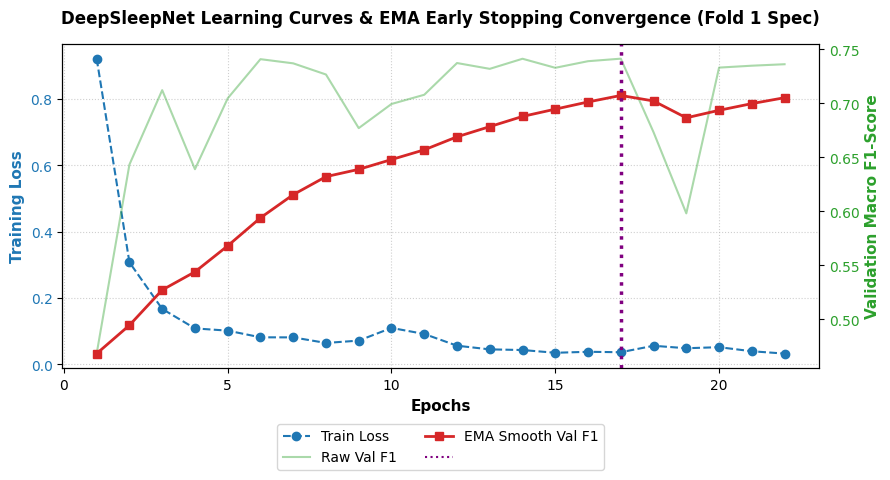

In [ ]:
# Chúng ta sẽ vẽ đồ thị Learning Curves đại diện cho Fold 1 để minh họa học trình
history_f1, best_ep_f1 = all_folds_history['Fold 1']
epochs_range = range(1, len(history_f1['train_loss']) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))

# Trục bên trái: Biểu diễn Train Loss (Đường màu xanh nét đứt)
color = '#1f77b4'
ax1.set_xlabel('Epochs', fontweight='bold', fontsize=11)
ax1.set_ylabel('Training Loss', color=color, fontweight='bold', fontsize=11)
line1 = ax1.plot(epochs_range, history_f1['train_loss'], color=color, linestyle='--', marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Trục bên phải: Biểu diễn Validation F1-Score & EMA F1-Score
ax2 = ax1.twinx()
color_f1 = '#2ca02c'
color_ema = '#d62728'
ax2.set_ylabel('Validation Macro F1-Score', color=color_f1, fontweight='bold', fontsize=11)
line2 = ax2.plot(epochs_range, history_f1['val_f1'], color=color_f1, linestyle='-', alpha=0.4, label='Raw Val F1')
line3 = ax2.plot(epochs_range, history_f1['ema_val_f1'], color=color_ema, linestyle='-', linewidth=2, marker='s', label='EMA Smooth Val F1')
ax2.tick_params(axis='y', labelcolor=color_f1)

# Vẽ đường thẳng đứng đánh dấu điểm Early Stopping tối ưu (Vị trí Model Best State được khôi phục)
ax2.axvline(x=best_ep_f1, color='purple', linestyle=':', linewidth=2.5, label=f'Best Model Restored (Ep {best_ep_f1})')

# Gộp các nhãn lại để làm Legend chung một góc
lines = line1 + line2 + line3 + [plt.Line2D([0], [0], color='purple', linestyle=':')]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)

plt.title("DeepSleepNet Learning Curves & EMA Early Stopping Convergence (Fold 1 Spec)",
          fontweight='bold', fontsize=12, pad=15)
fig.tight_layout()
plt.show()


📊 AVERAGE EVALUATION RESULTS OF DEEPSLEEPNET:
 - Accuracy:  0.4948
 - Precision: 0.4700
 - F1-Score:  0.4260
 - ROC-AUC:   0.7682


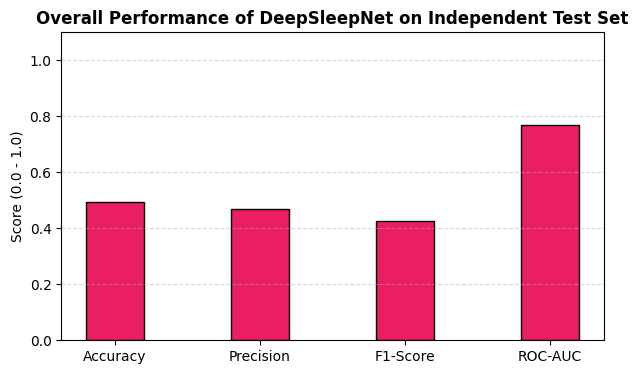

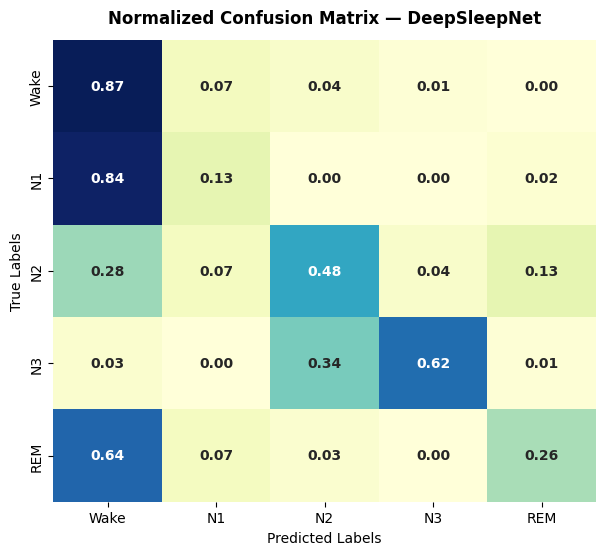

In [ ]:

# --- EXPORT TEST SET PERFORMANCE REPORT ---
avg_acc = np.mean([f['acc'] for f in fold_metrics])
avg_pre = np.mean([f['precision'] for f in fold_metrics])
avg_f1 = np.mean([f['f1'] for f in fold_metrics])
avg_auc = np.mean([f['roc_auc'] for f in fold_metrics])

print(f"\n📊 AVERAGE EVALUATION RESULTS OF DEEPSLEEPNET:")
print(f" - Accuracy:  {avg_acc:.4f}\n - Precision: {avg_pre:.4f}\n - F1-Score:  {avg_f1:.4f}\n - ROC-AUC:   {avg_auc:.4f}")


plt.figure(figsize=(7, 4))
plt.bar(
    ['Accuracy', 'Precision', 'F1-Score', 'ROC-AUC'],
    [avg_acc, avg_pre, avg_f1, avg_auc],
    color='#E91E63',
    width=0.4,
    edgecolor='black'
)

plt.title(
    "Overall Performance of DeepSleepNet on Independent Test Set",
    fontweight='bold'
)

plt.ylabel("Score (0.0 - 1.0)")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# Plot confusion matrix (aggregated)
cm = confusion_matrix(final_true, final_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False,
    annot_kws={"weight": "bold"}
)

plt.title(
    "Normalized Confusion Matrix — DeepSleepNet",
    fontweight='bold',
    pad=12
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()